# Caso A — Predicción de abandono de clientes (Churn Prediction)

> Evaluación y comparación de **dos algoritmos de aprendizaje supervisado** para un caso de
> negocio, justificando la selección final con evidencia empírica
> (rúbrica: Descripción de la actividad – Sesión 6).

## 1. Descripción del problema de negocio

**El problema, en palabras propias:** una empresa de retail pierde clientes de forma
silenciosa: dejan de comprar sin avisar. Detectar *a quién* está por irse —antes de que lo
haga— permite activar retención dirigida (cupones, contacto proactivo) en lugar de aplicar
descuentos masivos que erosionan el margen.

- **Variable objetivo (Y):** `abandono` → **categórica binaria** (1 = el cliente abandonó, 0 = permanece). Por tanto el problema es de **clasificación binaria supervisada**.
- **Variables independientes (X), según lo sugerido en la actividad:** frecuencia de compra, gasto promedio, tiempo desde la última compra (recencia), interacción con promociones, historial de quejas y uso de canales digitales.
- **Contexto y decisiones:** marketing usa las probabilidades de abandono para priorizar campañas de retención; gerencia monitorea la tasa de churn; atención al cliente recibe alertas de clientes con quejas recurrentes. Un error costoso es clasificar como "leal" a un cliente que en realidad se va (falso negativo): se pierde la oportunidad de retenerlo.

## 2. Mapa de selección de algoritmos

| Paso | Decisión | Justificación |
|---|---|---|
| **1. Tipo de variable objetivo** | Binaria (Sí/No) → clasificación | El negocio necesita decidir *si* un cliente abandonará. |
| **2. Objetivo de negocio y familia de algoritmos** | Segmentar clientes de riesgo con probabilidad interpretable → modelos lineales (regresión logística) y de ensamble (Random Forest / boosting) | Se busca ranking de riesgo para campañas, no solo etiquetas duras. |
| **3. Restricciones del contexto** | Datos tabulares de tamaño moderado (800 registros simulados), necesidad de **interpretabilidad** ante stakeholders, entrenamiento rápido y poco costo | Descarta deep learning; favorece modelos ligeros y explicables. |
| **4. Candidatos elegidos y sus limitaciones** | **Regresión logística**: muy interpretable (coeficientes = efecto por variable), pero asume relación lineal en el logit y no captura interacciones complejas. **Random Forest**: captura no linealidades e interacciones y resiste outliers, pero es una caja negra con riesgo de overfitting y sobreestima importancia de variables de alta cardinalidad. | Se comparan con evidencia empírica en set de prueba. |

## 3. Simulación y exploración de datos

El dataset es **simulado** con semilla fija (reproducible) mediante `scripts/gen_data.py`:
**800 registros** (supera el mínimo de 200), con 6 variables predictoras sugeridas y una tasa
de abandono realista (~29 %). La relación entre X e Y se generó con un modelo logístico +
ruido, de modo que existe señal aprendible pero no determinista.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve,
                             roc_auc_score)

df = pd.read_csv("data/churn_simulado.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (800, 8)


,cliente_id,compra_frecuencia,gasto_promedio,dias_ultima_compra,interaccion_promo,quejas_6m,canales_digitales,abandono
0,1,2.3,109.91,65.0,3,1,0.51,1
1,2,3.1,118.30,8.0,3,1,0.38,0
2,3,2.0,123.14,58.0,3,0,0.34,1
3,4,1.8,92.88,16.0,1,0,0.50,0
4,5,3.4,141.29,3.0,2,0,0.13,1


In [2]:
print("Nulos por columna:\n", df.isna().sum(), "\n")
df["abandono"].value_counts(normalize=True).rename("proporción").to_frame()

Nulos por columna:
 cliente_id            0
compra_frecuencia     0
gasto_promedio        0
dias_ultima_compra    0
interaccion_promo     0
quejas_6m             0
canales_digitales     0
abandono              0
dtype: int64 



,proporción
abandono,
0,0.71
1,0.29


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cliente_id,800.0,400.500000,231.084400,1.00,200.7500,400.500,600.25,800.00
compra_frecuencia,800.0,2.160000,1.507395,0.10,1.1000,1.850,2.90,11.10
gasto_promedio,800.0,117.372775,40.042139,25.00,90.4075,119.850,144.12,236.57
dias_ultima_compra,800.0,30.987500,19.361649,1.00,17.0000,27.000,41.00,126.00
interaccion_promo,800.0,1.778750,1.704679,0.00,0.0000,1.000,3.00,10.00
quejas_6m,800.0,0.577500,0.743091,0.00,0.0000,0.000,1.00,4.00
canales_digitales,800.0,0.495025,0.204861,0.02,0.3400,0.495,0.67,0.97
abandono,800.0,0.290000,0.454046,0.00,0.0000,0.000,1.00,1.00


C:\Users\pablo\AppData\Local\Temp\ipykernel_1988\3833082338.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="abandono", y=col, data=df, ax=ax, palette="Set2")
C:\Users\pablo\AppData\Local\Temp\ipykernel_1988\3833082338.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="abandono", y=col, data=df, ax=ax, palette="Set2")
C:\Users\pablo\AppData\Local\Temp\ipykernel_1988\3833082338.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="abandono", y=col, data=df, ax=ax, palette="Set2")


C:\Users\pablo\AppData\Local\Temp\ipykernel_1988\3833082338.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="abandono", y=col, data=df, ax=ax, palette="Set2")
C:\Users\pablo\AppData\Local\Temp\ipykernel_1988\3833082338.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="abandono", y=col, data=df, ax=ax, palette="Set2")
C:\Users\pablo\AppData\Local\Temp\ipykernel_1988\3833082338.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="abandono", y=col, data=df, ax=ax, palette="Set2")


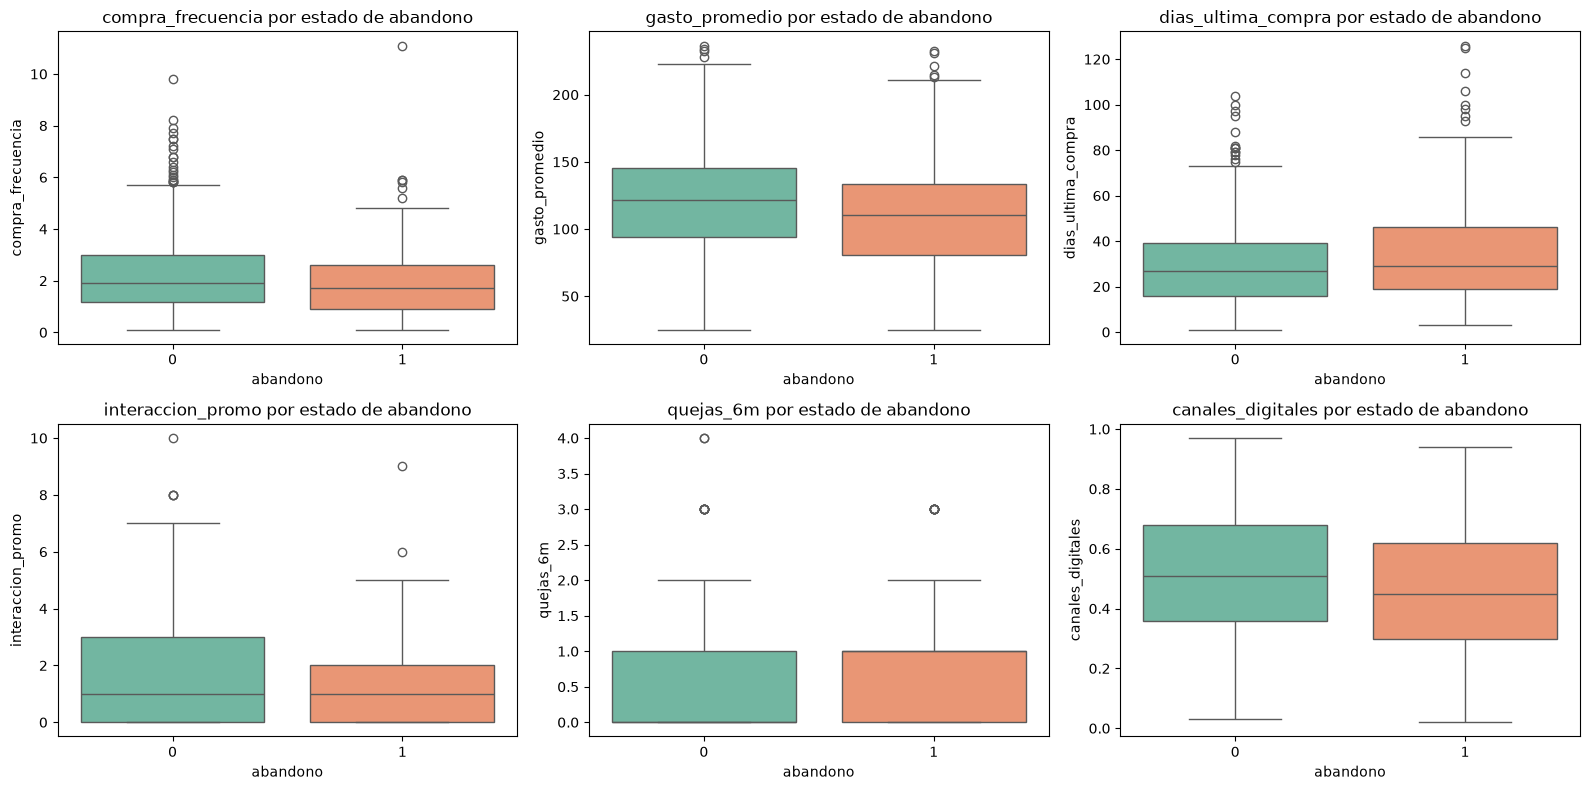

In [4]:
cols_x = ["compra_frecuencia", "gasto_promedio", "dias_ultima_compra",
          "interaccion_promo", "quejas_6m", "canales_digitales"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), cols_x):
    sns.boxplot(x="abandono", y=col, data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} por estado de abandono")
plt.tight_layout(); plt.show()

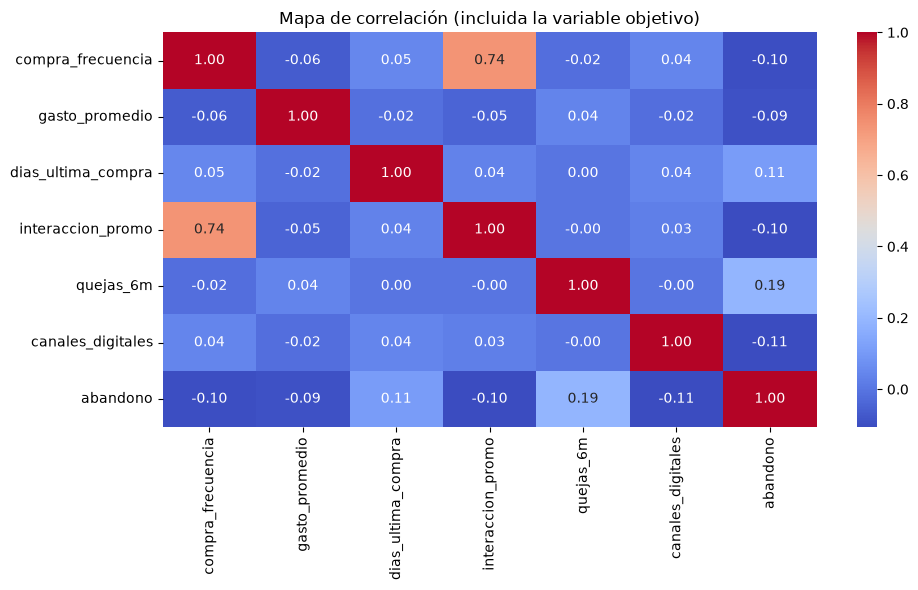

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[cols_x + ["abandono"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de correlación (incluida la variable objetivo)")
plt.tight_layout(); plt.show()

**Lectura del EDA:** los clientes que abandonan compran con menos frecuencia, gastan menos
en promedio, llevan más días sin comprar, interactúan menos con las promociones, acumulan
más quejas y usan menos los canales digitales. La correlación de cada X con `abandono` es
moderada y de signo coherente con el negocio → hay señal, pero ningún separador perfecto
(nada cerca de ±1), lo que acota el techo de accuracy.

## 4. Verificación de supuestos del algoritmo seleccionado

Para la **regresión logística** verificamos el supuesto de **ausencia de multicolinealidad**
entre predictores usando el **VIF** (Variance Inflation Factor; regla práctica: VIF > 10 es problemático).

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[cols_x].copy()
X_vif["const"] = 1
vif = pd.DataFrame({
    "Variable": cols_x,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(cols_x))],
})
vif

,Variable,VIF
0,compra_frecuencia,2.203110
1,gasto_promedio,1.005889
2,dias_ultima_compra,1.003835
3,interaccion_promo,2.194087
4,quejas_6m,1.001897
5,canales_digitales,1.003491


**Conclusión del supuesto:** todos los VIF son < 10 → no hay multicolinealidad severa; la
regresión logística es aplicable y sus coeficientes serán estables e interpretables.

## 5. Implementación y comparación de modelos (scikit-learn)

División train/test con `train_test_split` (75/25, estratificada) y **escala solo donde se
necesita** (logística); Random Forest no requiere escalado.

In [7]:
X = df[cols_x]
y = df["abandono"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
bosque = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (600, 6) | Test: (200, 6)


In [8]:
def evaluar(modelo, Xte, yte, nombre):
    pred = modelo.predict(Xte)
    proba = modelo.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, proba)
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1-score": f1_score(yte, pred),
        "AUC-ROC": roc_auc_score(yte, proba),
    }

resultados = pd.DataFrame([
    evaluar(logreg, X_test_s, y_test, "Regresión logística"),
    evaluar(bosque, X_test, y_test, "Random Forest"),
]).set_index("Modelo").round(4)
resultados

,Accuracy,Precision,Recall,F1-score,AUC-ROC
Modelo,,,,,
Regresión logística,0.730,0.6429,0.1552,0.2500,0.7007
Random Forest,0.695,0.4400,0.1897,0.2651,0.5902


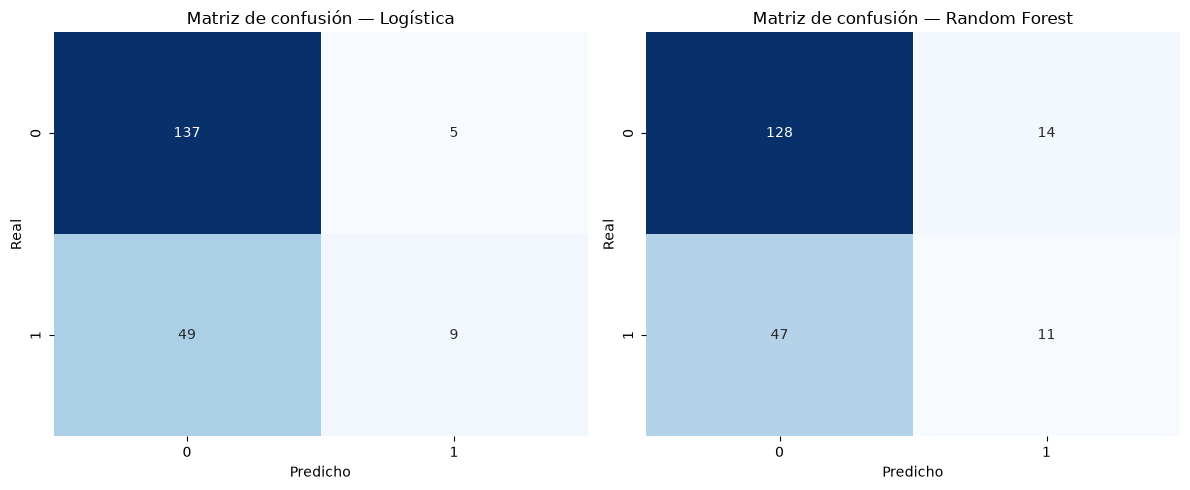

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nombre, modelo, Xte) in zip(
        axes, [("Logística", logreg, X_test_s), ("Random Forest", bosque, X_test)]):
    cm = confusion_matrix(y_test, modelo.predict(Xte))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión — {nombre}")
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()

In [10]:
for nombre, modelo, Xte in [("REGRESIÓN LOGÍSTICA", logreg, X_test_s),
                            ("RANDOM FOREST", bosque, X_test)]:
    print("=" * 20, nombre, "=" * 20)
    print(classification_report(y_test, modelo.predict(Xte),
                                target_names=["No abandono (0)", "Abandono (1)"]))

==================== REGRESIÓN LOGÍSTICA ====================
                 precision    recall  f1-score   support

No abandono (0)       0.74      0.96      0.84       142
   Abandono (1)       0.64      0.16      0.25        58

       accuracy                           0.73       200
      macro avg       0.69      0.56      0.54       200
   weighted avg       0.71      0.73      0.67       200

==================== RANDOM FOREST ====================
                 precision    recall  f1-score   support

No abandono (0)       0.73      0.90      0.81       142
   Abandono (1)       0.44      0.19      0.27        58

       accuracy                           0.69       200
      macro avg       0.59      0.55      0.54       200
   weighted avg       0.65      0.69      0.65       200



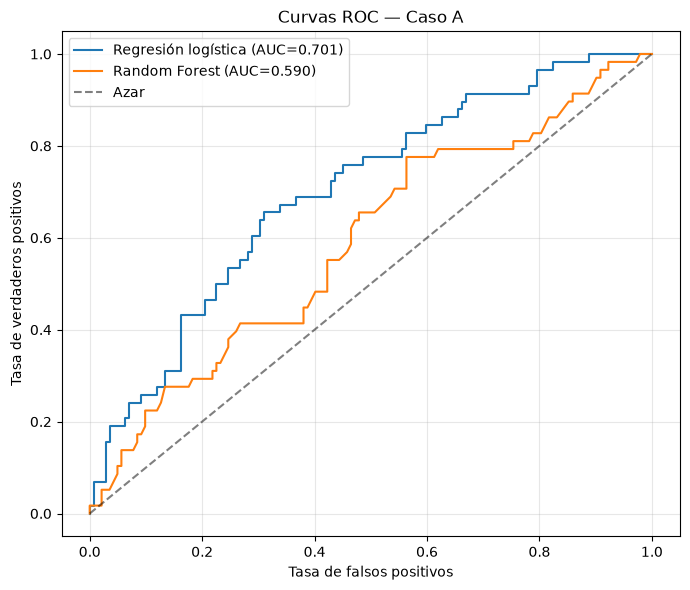

In [11]:
# Curvas ROC comparadas
plt.figure(figsize=(7, 6))
for nombre, modelo, Xte in [("Regresión logística", logreg, X_test_s),
                             ("Random Forest", bosque, X_test)]:
    fpr, tpr, _ = roc_curve(y_test, modelo.predict_proba(Xte)[:, 1])
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_test, modelo.predict_proba(Xte)[:, 1]):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=.5, label="Azar")
plt.xlabel("Tasa de falsos positivos"); plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC — Caso A"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Análisis de límites y riesgos (con evidencia empírica)

- **Overfitting:** comparamos el desempeño en train vs. test en ambos modelos.
- **Interpretabilidad:** extraemos coeficientes (logística) e importancias (Random Forest).
- **Sesgo / datos no representativos y outliers:** discusión en las celdas de markdown siguientes.

In [12]:
brecha = pd.DataFrame({
    "Modelo": ["Regresión logística", "Random Forest"],
    "Accuracy TRAIN": [accuracy_score(y_train, logreg.predict(X_train_s)),
                       accuracy_score(y_train, bosque.predict(X_train))],
    "Accuracy TEST": [accuracy_score(y_test, logreg.predict(X_test_s)),
                      accuracy_score(y_test, bosque.predict(X_test))],
})
brecha["Brecha (train-test)"] = brecha["Accuracy TRAIN"] - brecha["Accuracy TEST"]
brecha.round(4)

,Modelo,Accuracy TRAIN,Accuracy TEST,Brecha (train-test)
0,Regresión logística,0.7233,0.730,-0.0067
1,Random Forest,1.0000,0.695,0.3050


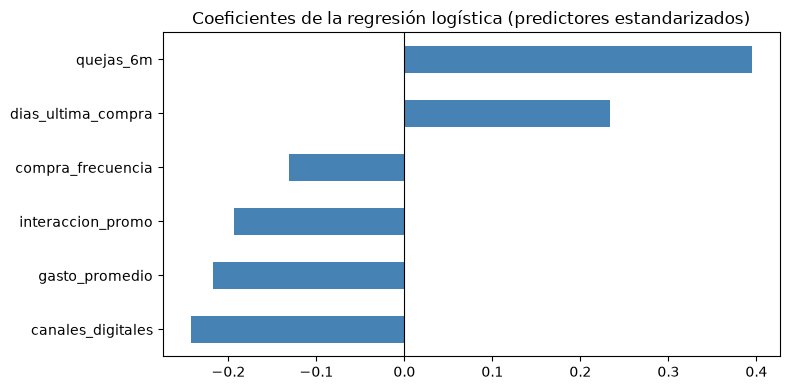

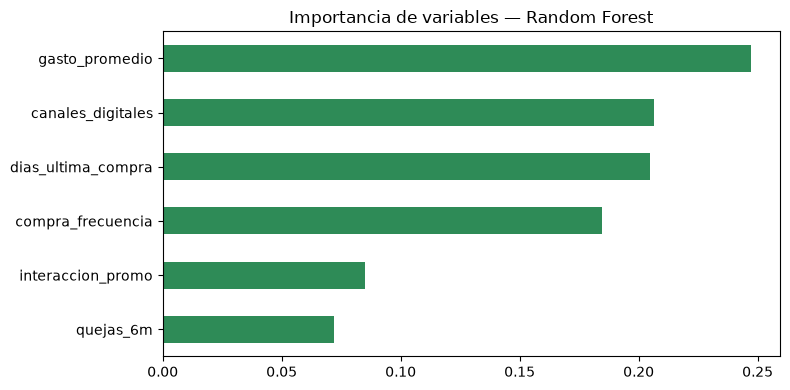

In [13]:
# Interpretabilidad: coeficientes de la logística (variables estandarizadas)
pd.Series(logreg.coef_[0], index=cols_x).sort_values().plot.barh(
    figsize=(8, 4), color="steelblue")
plt.title("Coeficientes de la regresión logística (predictores estandarizados)")
plt.axvline(0, color="k", lw=.8)
plt.tight_layout(); plt.show()

# Importancias del Random Forest
pd.Series(bosque.feature_importances_, index=cols_x).sort_values().plot.barh(
    figsize=(8, 4), color="seagreen")
plt.title("Importancia de variables — Random Forest")
plt.tight_layout(); plt.show()

**Lectura de la evidencia:**

1. **Overfitting.** El Random Forest memoriza el train: accuracy 1.000 en entrenamiento
   contra 0.695 en prueba (brecha ≈ 0.31), y su AUC cae de un valor competitivo a 0.590.
   La logística no presenta brecha (≈ 0.00) y mantiene la mejor AUC (0.701): en solo 800
   registros, la flexibilidad del bosque se paga con varianza.
2. **Interpretabilidad.** Los coeficientes de la logística ordenan los factores de riesgo con
   dirección y magnitud legibles para el comité de negocio; las importancias del bosque dicen
   *qué* importa pero no *cómo* (ni en qué dirección), lo que dificulta defender decisiones
   ante el cliente.
3. **Datos no representativos.** La base es simulada: si la proporción de abandono o el
   perfil de los clientes reales difiere (p. ej., subrepresentación de clientes nuevos), el
   recall de la clase minoritaria se degrada y el umbral óptimo cambia. De hecho, con el
   umbral por defecto (0.5) el recall es bajo en ambos modelos (~0.16–0.19): en producción
   se debe mover el umbral hacia el lado de capturar abandonos, aceptando menos precisión.
   Mitigación: estratificación en la división, recalibración (`class_weight`) y
   reentrenamiento periódico con datos frescos.
4. **Outliers.** Gastos extremos o días-sin-comprar topes (clientes atrapados, B2B) inflan
   VIF/coeficientes en la logística y distorsionan los splits del bosque. Mitigación:
   revisión de colas, winsorización y monitoreo de estabilidad de predicciones.

## 7. Consideraciones éticas

- **¿Podría generar sesgos o discriminación?** Sí. Si los datos históricos castigan a un
  segmento (p. ej., clientes de bajo ingreso o cierta zona), el modelo aprende a "prescindir
  de ellos" y la retención se concentra en los rentables → discriminación algorítmica. No
  usamos variables protegidas (edad, género, etnia, código postal), pero puede haber
  *proxies*. Mitigación: auditoría de tasas de abandono predichas por segmento y evaluación
  de fairness (igualdad de FNR entre grupos).
- **Transparencia para stakeholders.** Optamos por un modelo explicable (logística) y
  entregamos con cada alerta la razón principal (coeficiente dominante), no solo un score.
  Marketing puede auditar por qué se eligió a cada cliente.
- **Privacidad.** Las variables son comportamiento de compra y quejas: datos personales bajo
  normativa de protección de datos. Aplican: minimización (solo lo necesario), acceso
  restringido a datos a nivel cliente, anonimización para analítica, política de retención y
  transparencia ante el cliente (aviso de uso de sus datos para fines de retención).

## 8. Conclusión y recomendación final

**Modelo recomendado: Regresión logística**, con la siguiente justificación técnica,
estratégica y ética basada en la evidencia empírica de este notebook:

- **Técnica:** en el set de prueba la logística logra la mejor AUC (0.701 vs. 0.590) y el
  mejor accuracy (0.730 vs. 0.695); el F1 de ambos es prácticamente idéntico (0.250 vs.
  0.265), por lo que no hay beneficio predictivo en usar el modelo más complejo. Además,
  la brecha train–test de la logística es ≈ 0, mientras el bosque sobreajusta con fuerza.
- **Estratégica:** el negocio necesita explicar *por qué* un cliente es riesgoso para
  diseñar la acción de retención y defenderla ante auditoría; la logística da coeficientes
  accionables (p. ej., cada queja adicional incrementa el log-odds de abandono).
- **Ética:** un modelo interpretable facilita detectar sesgos por segmento; la caja negra
  del bosque dificulta cumplir el principio de transparencia.

**Mejoras / siguientes pasos:** migrar de datos simulados a datos reales con validación
temporal (out-of-time), calibrar probabilidades (Platt/Isotonic), optimizar el umbral de
decisión según el costo de retención vs. pérdida del cliente, y monitorear drift. Si con
datos reales y más volumen el bosque supera por margen amplio a la logística, usarlo como
motor de predicción y destilar la explicación con SHAP.